In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.DataFrame(load_breast_cancer().data, columns =load_breast_cancer().feature_names)

df['target'] = load_breast_cancer().target

df.head()

df.shape

df.isnull().sum()

df.describe()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

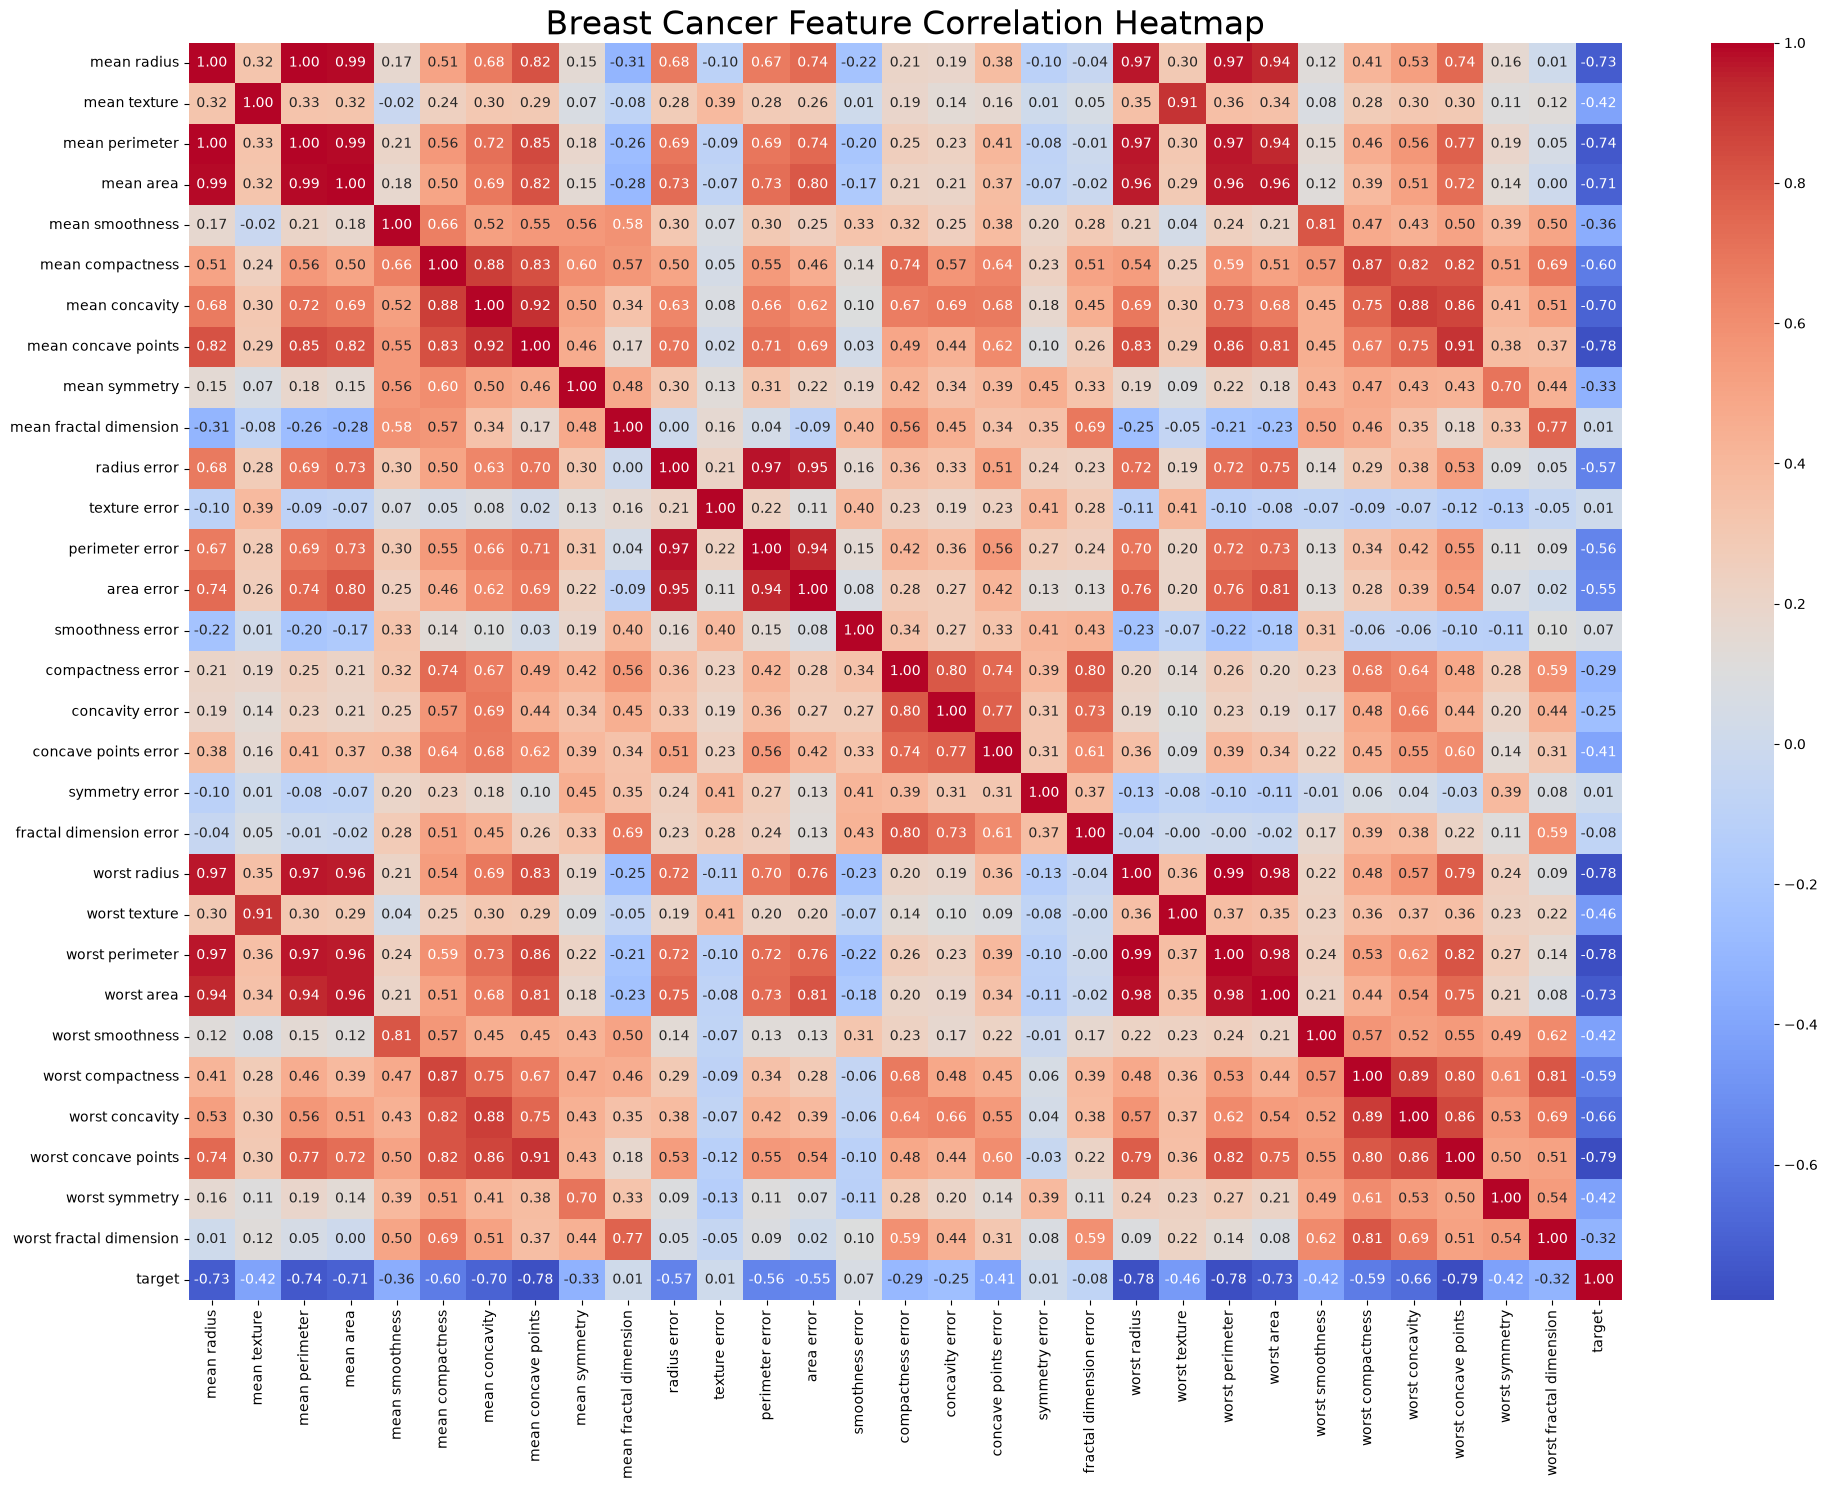

In [3]:
corr_matrix = df.corr()
plt.figure(figsize= (20, 15))
sns.heatmap(corr_matrix, annot= True, cmap = 'coolwarm', fmt = ".2f")
plt.title("Breast Cancer Feature Correlation Heatmap", fontsize = 24)
plt.tight_layout()
plt.show()

In [5]:
corr_matrix = df.corr()['target'].abs()
corr_matrix['target'] = 0

threshold = 0.6

high_corr_target_cols = corr_matrix[corr_matrix > threshold]

print(len(high_corr_target_cols))
print(high_corr_target_cols)

10
mean radius             0.730029
mean perimeter          0.742636
mean area               0.708984
mean concavity          0.696360
mean concave points     0.776614
worst radius            0.776454
worst perimeter         0.782914
worst area              0.733825
worst concavity         0.659610
worst concave points    0.793566
Name: target, dtype: float64


In [6]:
X = load_breast_cancer().data

y = load_breast_cancer().target

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size= 0.2,
                                                    random_state = 42,
                                                    #stratify = y
                                                    )

In [7]:
model_rf_clf = RandomForestClassifier(
    n_estimators = 10,
    random_state= 42
)

model_rf_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [8]:
print("="*15, "Model Testing", "="*15)

y_pred_test_rf = model_rf_clf.predict(X_test) # unseen data
y_pred_train_rf = model_rf_clf.predict(X_train) # model has seeen these inputs

test_acc_rf = accuracy_score(y_test, y_pred_test_rf) # Testing accuracy
train_acc_rf = accuracy_score(y_train, y_pred_train_rf) #  Training accuracy

print("====== Random Forest Evaluation ======")
print(f"Testing Accuracy: {test_acc_rf*100:.2f}%")
print(f"Training Accuracy: {train_acc_rf*100:.2f}%")

=============== Model Testing ===============
====== Random Forest Evaluation ======
Testing Accuracy: 95.61%
Training Accuracy: 99.78%


In [9]:
importances = model_rf_clf.feature_importances_
feature_names = load_breast_cancer().feature_names

df_feature_importance = pd.DataFrame({
    'features': feature_names,
    'importance': importances
})

df_top_features = df_feature_importance.sort_values(by= 'importance', ascending = False)
top_features = df_top_features.head(15)['features'].reset_index(drop = True)
top_features

0     worst concave points
1      mean concave points
2               worst area
3             worst radius
4              mean radius
5               area error
6             radius error
7           mean perimeter
8        worst compactness
9          worst perimeter
10         worst concavity
11           worst texture
12         concavity error
13               mean area
14         mean smoothness
Name: features, dtype: str

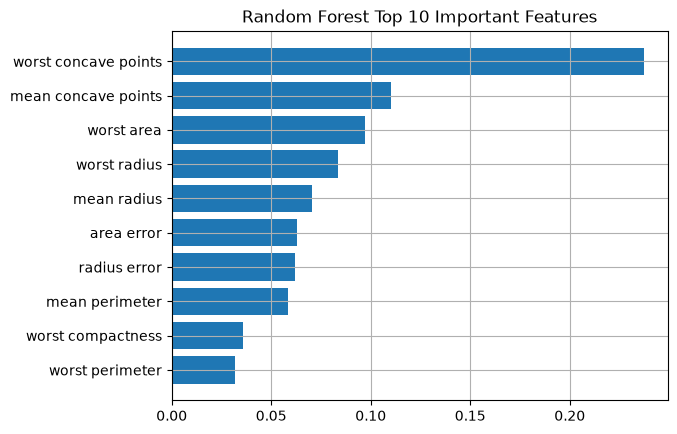

In [10]:
plt.barh(df_top_features['features'].head(10), df_top_features['importance'].head(10))
plt.gca().invert_yaxis() # invert the axis --- largest on TOP

plt.title("Random Forest Top 10 Important Features")
plt.grid()
plt.show()

In [11]:
X = df[list(top_features)]

y = load_breast_cancer().target

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size= 0.2,
                                                    random_state = 42)



In [23]:
model_rf_clf = RandomForestClassifier(
    n_estimators = 10,
    max_depth = 3,
    random_state= 42
)

model_rf_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: 

In [24]:
print("="*15, "Model Testing", "="*15)

y_pred_test_rf = model_rf_clf.predict(X_test) # unseen data
y_pred_train_rf = model_rf_clf.predict(X_train) # model has seeen these inputs

test_acc_rf = accuracy_score(y_test, y_pred_test_rf) # Testing accuracy
train_acc_rf = accuracy_score(y_train, y_pred_train_rf) #  Training accuracy

print("====== Random Forest Evaluation ======")
print(f"Testing Accuracy: {test_acc_rf*100:.2f}%")
print(f"Training Accuracy: {train_acc_rf*100:.2f}%")

=============== Model Testing ===============
====== Random Forest Evaluation ======
Testing Accuracy: 97.37%
Training Accuracy: 97.36%


In [25]:
import pickle

with open("new_breast_cancer_model.pkl", "wb") as f:
    pickle.dump(model_rf_clf, f)

In [42]:
import joblib

model = joblib.dump(model_rf_clf, 'new_breast_cancer_model.pkl')

In [ ]:
#pip install gradio

In [27]:
import warnings
warnings.filterwarnings("ignore")

In [28]:
import gradio as gr

In [29]:
list(top_features)

['worst concave points',
 'mean concave points',
 'worst area',
 'worst radius',
 'mean radius',
 'area error',
 'radius error',
 'mean perimeter',
 'worst compactness',
 'worst perimeter',
 'worst concavity',
 'worst texture',
 'concavity error',
 'mean area',
 'mean smoothness']

In [43]:
input_cols = ['worst concave points',
 'mean concave points',
 'worst area',
 'worst radius',
 'mean radius',
 'area error',
 'radius error',
 'mean perimeter',
 'worst compactness',
 'worst perimeter',
 'worst concavity',
 'worst texture',
 'concavity error',
 'mean area',
 'mean smoothness']

model = joblib.load('new_breast_cancer_model.pkl')

model.predict([[0.1015, 0.03821, 677.9, 14.97, 12.47, 30.29, 0.3961, 81.09, 0.2378, 96.05, 0.2671, 24.64, 0.02701, 481.9, 0.09965]])
model.predict([[0.1789, 0.07951, 1866.0, 24.86, 18.94, 96.05, 0.7888, 123.6, 0.2336, 165.9, 0.2687, 26.58, 0.02269, 1130.0, 0.09009]])

array([0])

In [46]:
def predict_cancer(worst_concave_points, mean_concave_points, worst_area,worst_radius):
    input_values = [worst_concave_points, mean_concave_points, worst_area,worst_radius, 0,0,0,0,0,0,0,0,0,0,0]

    input_values = [worst_concave_points, mean_concave_points, worst_area, worst_radius, 14.13, 40.34, 0.41, 91.97, 0.25, 107.26, 0.27, 25.68, 0.03, 654.89, 0.1]
   
    model = joblib.load('new_breast_cancer_model.pkl')
   
    result = model.predict([input_values])
   
    if result == 0:
        return 'Yes, Cancer is present'
    else:
        return 'No, There is no cancer!'

In [ ]:
app = gr.Interface(
    fn = predict_cancer,
    inputs = [
        gr.Slider(minimum=0.00, maximum=0.291, step=1, label= "Worst Concave Points"),
        gr.Slider(minimum=0.00, maximum=0.291, step=1, label= "Mean Concave Points"),
        gr.Slider(minimum=185.20, maximum=4254.0, step=1, label= "Worst Area"),
        gr.Slider(minimum=7.93, maximum=36.04, step=1, label= "Worst Radius")
    ],
    outputs = 'text',
    title = 'Breast Cancer Detection App',
    description = 'Enter your medical exam report values, and get prediction'
)
 
app.launch(share = True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://6da58fe9d35c62c434.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
#pip install streamlit

In [51]:
import streamlit as st

st.title("Breast Cancer Detection App")

2026-07-03 16:36:03.848 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-03 16:36:04.555 
  command:

    streamlit run C:\Users\Nurfatini Nasuha\AppData\Roaming\Python\Python314\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-03 16:36:04.557 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-03 16:36:04.560 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()